<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [3]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [6]:
print(df.info())
print(df.isnull().sum())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [7]:
print(df.describe())

         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857       24.343232        22.96522   
std         18.422661       21.833836       27.089360        27.01774   
min          0.000000        0.000000        0.000000         0.00000   
25%          0.000000 

### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [11]:
print(df['Country'].unique())
print(df['Country'].value_counts())

<StringArray>
[                               'USA',                                 'UK',
                             'Canada',                             'Norway',
                         'Uzbekistan',                             'Serbia',
                             'Poland',                        'Philippines',
                           'Bulgaria',                        'Switzerland',
 ...
              'Saint Kitts and Nevis',                             'Monaco',
 'Micronesia, Federated States of...',                              'Haiti',
                                  nan,                              'Nauru',
                            'Liberia',                               'Chad',
                           'Djibouti',                    'Solomon Islands']
Length: 186, dtype: str
Country
USA                11095
Germany             4947
India               4231
UK                  3224
Ukraine             2672
                   ...  
Haiti                  1
Naur

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [10]:
df['Country'] = df['Country'].str.strip()
df['Country'] = df['Country'].replace({'United States of America': 'USA', 'United Kingdom of Great Britain and Northern Ireland': 'UK'})
print(df['EdLevel'].unique())

<StringArray>
[                                                         'Primary/elementary school',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                                    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                             'Some college/university study without earning a degree',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                                                     'Something else',
                                                                                  nan]
Length: 9, dtype: str


### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [12]:
df = pd.get_dummies(df, columns=['Employment'], prefix='Emp')
print(df.head())

   ResponseId                      MainBranch                 Age RemoteWork  \
0           1  I am a developer by profession  Under 18 years old     Remote   
1           2  I am a developer by profession     35-44 years old     Remote   
2           3  I am a developer by profession     45-54 years old     Remote   
3           4           I am learning to code     18-24 years old        NaN   
4           5  I am a developer by profession     18-24 years old        NaN   

    Check                                   CodingActivities  \
0  Apples                                              Hobby   
1  Apples  Hobby;Contribute to open-source projects;Other...   
2  Apples  Hobby;Contribute to open-source projects;Other...   
3  Apples                                                NaN   
4  Apples                                                NaN   

                                             EdLevel  \
0                          Primary/elementary school   
1       Bachelor’s deg

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [13]:
missing_data = df.isnull().sum().sort_values(ascending=False)
print(missing_data)

AINextMuch less integrated                                       64289
AINextLess integrated                                            63082
AINextNo change                                                  52939
AINextMuch more integrated                                       51999
EmbeddedAdmired                                                  48704
                                                                 ...  
Emp_Student, full-time;Student, part-time;Employed, part-time        0
Emp_Student, full-time;Student, part-time;Retired                    0
Emp_Student, part-time                                               0
Emp_Student, part-time;Employed, part-time                           0
Emp_Student, part-time;Retired                                       0
Length: 223, dtype: int64


<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [14]:
median_comp = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_comp)

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [15]:
mode_remote = df['RemoteWork'].mode()[0]
df['RemoteWork'] = df['RemoteWork'].fillna(mode_remote)

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [16]:
# this is for me only (X-X_min)/(x_max-xmin)
df['ConvertedComp_Normalized'] = (df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()) / (df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min())

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


<Axes: title={'center': 'Transformed Data'}, ylabel='Frequency'>

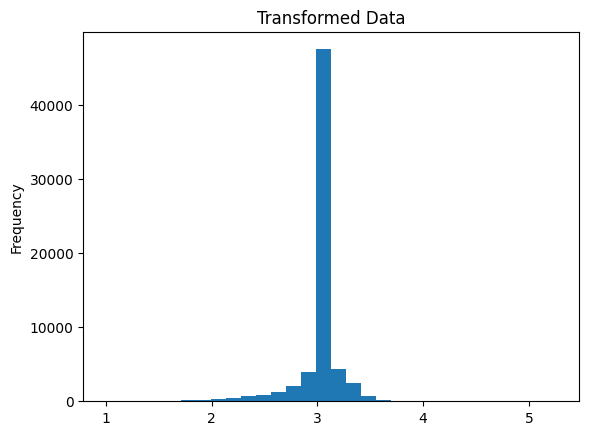

In [17]:
df['ConvertedCompYearly_Transformed'] = df['ConvertedCompYearly'] ** 0.1
df['ConvertedCompYearly_Transformed'].plot(kind='hist', bins=30, title='Transformed Data')

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [19]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce').fillna(0)
df['ExperienceLevel'] = 'Unknown'
df.loc[df['YearsCodePro'] < 2, 'ExperienceLevel'] = 'Jnr'
df.loc[(df['YearsCodePro'] >= 2) & (df['YearsCodePro'] < 5), 'ExperienceLevel'] = 'Mid'
df.loc[(df['YearsCodePro'] >= 5) & (df['YearsCodePro'] < 10), 'ExperienceLevel'] = 'Snr'
df.loc[df['YearsCodePro'] >= 10, 'ExperienceLevel'] = 'Expt'

print(df[['YearsCodePro', 'ExperienceLevel']].head())

   YearsCodePro ExperienceLevel
0           0.0             Jnr
1          17.0            Expt
2          27.0            Expt
3           0.0             Jnr
4           0.0             Jnr


### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
